In [ ]:
from google.colab import auth; auth.authenticate_user()
from google.colab import drive; drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

In [ ]:
import pandas as pd
df = pd.read_csv("/content/country_timeseries.csv")

In [ ]:
#Ordino le date dei casi dai più vecchi
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df.head()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone,Cases_Nigeria,Cases_Senegal,Cases_UnitedStates,Cases_Spain,Cases_Mali,Deaths_Guinea,Deaths_Liberia,Deaths_SierraLeone,Deaths_Nigeria,Deaths_Senegal,Deaths_UnitedStates,Deaths_Spain,Deaths_Mali
121,2014-03-22,0,49.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,2014-03-24,2,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,2014-03-25,3,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118,2014-03-26,4,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,2014-03-27,5,103.0,8.0,6.0,NaN,NaN,NaN,NaN,NaN,66.0,6.0,5.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Scelgo un paese e ricavo i nuovi casi giornalieri
country = "Guinea"
df_seir_Gu = df [['Date', f'Cases_{country}', f'Deaths_{country}']].copy()
df_seir_Gu = df_seir_Gu.dropna()
df_seir_Gu["New_cases"] = df_seir_Gu["Cases_Guinea"].diff().fillna(0)

df_seir_Gu.head()

,Date,Cases_Guinea,Deaths_Guinea,New_cases
121,2014-03-22,49.0,29.0,0.0
120,2014-03-24,86.0,59.0,37.0
119,2014-03-25,86.0,60.0,0.0
118,2014-03-26,86.0,62.0,0.0
117,2014-03-27,103.0,66.0,17.0


Definisco equazioni SEIR:

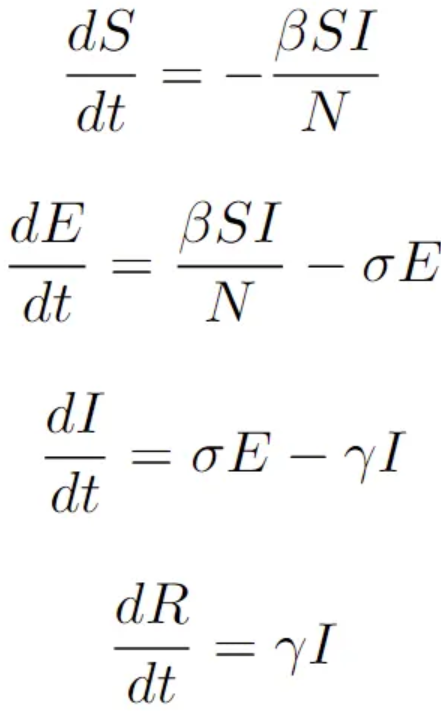



In [ ]:
#Definisce le ODE del sistema e fisso le condizioni iniziali, i parametri beta, gamma, sigma
#li fisso inizialmente

from scipy.integrate import odeint
import matplotlib.pyplot as plt

N = 10000000
beta = 0.3
sigma = 1/7 #incubazione 7 giorni
gamma = 1/15 #guarigione in 15 giorni
t = np.arange(160)
#Condizioni iniziali
I0 = 49
I_data = df_seir_Gu["Cases_Guinea"].values
E0 = (gamma/sigma)*I0 # Esposti ma non ancora contagiosi e asintomatici

R0 = 0
S0 = N -I0-R0-E0

y0 = S0, E0, I0, R0


def seir_model(y, t, N, beta, sigma, gamma):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return dSdt, dEdt, dIdt, dRdt

ret = odeint(seir_model, y0, t, args=(N, beta, sigma, gamma))
S, E, I, R = ret.T


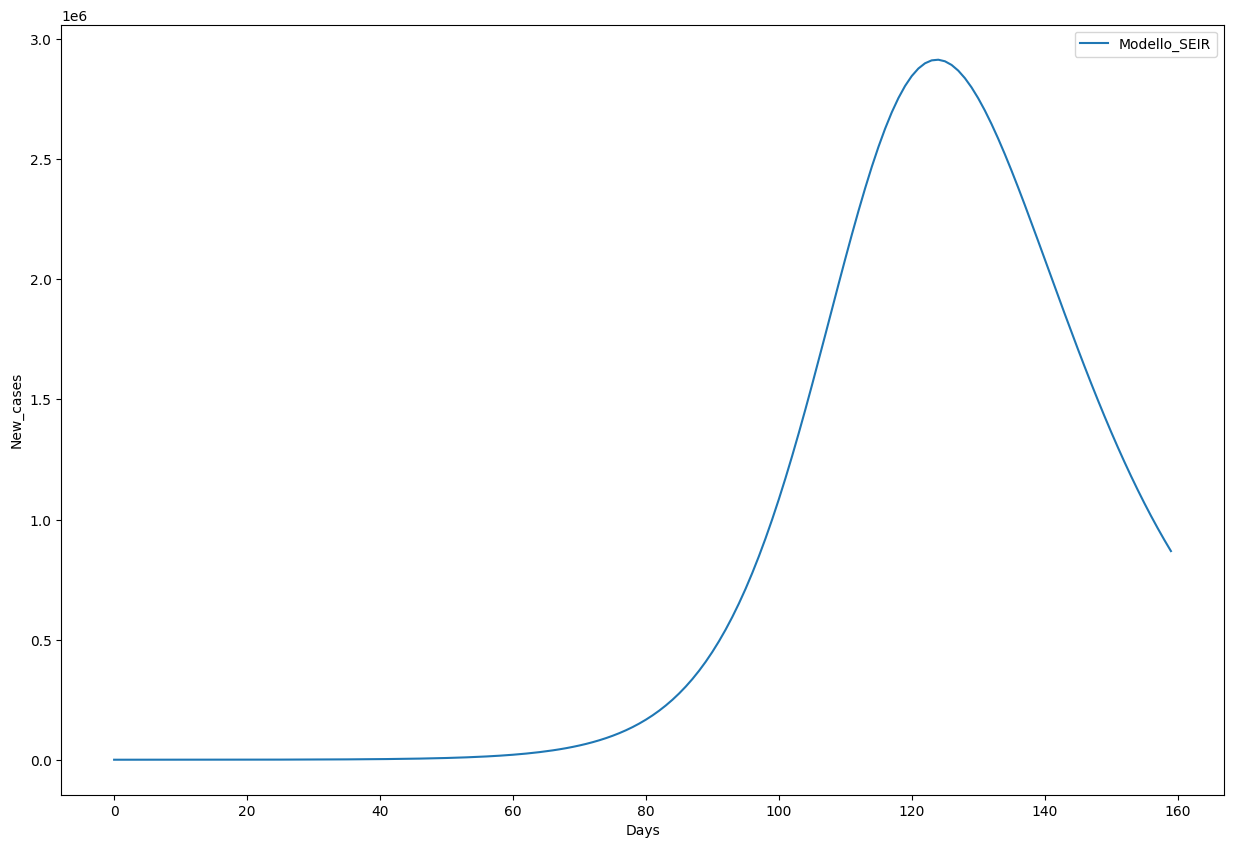

In [ ]:
plt.figure(figsize=(15, 10))
plt.plot(t, I, label='Modello_SEIR')


plt.xlabel('Days')
plt.ylabel('New_cases')
plt.legend()
plt.show()


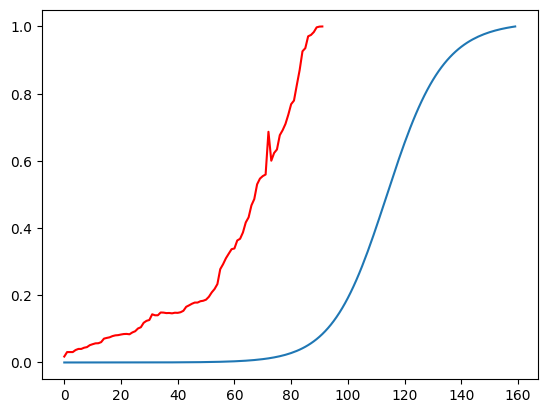

In [ ]:
#Confronto tra dataset e modello SEIR
plt.plot(t[:len(I_data)], I_data /max(I_data)  , label="Dati reali", color="red")
plt.plot(t, (I+R)/max(I+R), label='Modello_SEIR')

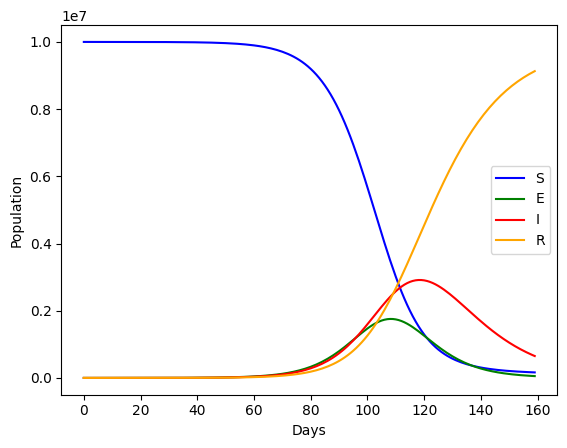

In [ ]:
plt.plot(t, S, label='S', color = "blue")
plt.plot(t, E, label='E', color = "green")
plt.plot(t, I, label='I', color ="red")
plt.plot(t, R, label='R', color = "orange")
plt.xlabel('Days')
plt.ylabel('Population')
plt.legend()
plt.show()

In [ ]:
#Definisco funzione loss per calcolare errore tra modello SEIR e dataset
from scipy.optimize import minimize
t = np.arange(len(I_data))
def loss (params):
  beta, sigma, gamma  = params
  ret = odeint(seir_model, y0, t, args=(N, beta, sigma, gamma))
  S, E, I, R = ret.T
  return  np.mean((np.log(I + R + 1) - np.log(I_data + 1))**2)  #uso mean squared error e ne prendo il log

#Uso i valori iniziali dei parametri che usato prima poi cerco i valori che mi minimizzano l'errore
initial_guess = [0.3, 1/7, 1/15]
bounds = [
    (1e-6, 3),    #beta
    (1e-6, 1),    #sigma     ##necessario per evitare parametri negativi
    (1e-6, 1)     #gamma
]


result = minimize(loss, initial_guess, bounds =bounds )
beta_opt, sigma_opt, gamma_opt = result.x

print("Best fit parameters:", beta_opt, sigma_opt, gamma_opt)

###Risolvo il modello SEIR con i nuovi parametri ottimizzati
ret = odeint(seir_model, y0, t, args=(N, beta_opt, sigma_opt, gamma_opt))
S, E, I, R = ret.T



Best fit parameters: 0.35018678326133024 0.20384516150972745 0.3049496254175581


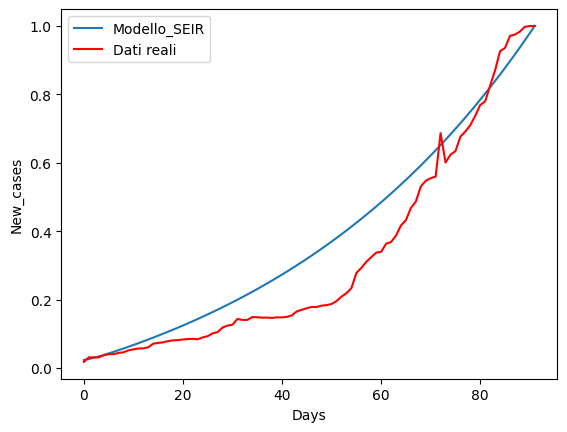

In [ ]:
plt.plot(t, (I+R)/max(I+R), label='Modello_SEIR')
plt.plot(t, I_data /max(I_data) , label="Dati reali", color="red")
plt.xlabel('Days')
plt.ylabel('New_cases')
plt.legend()
plt.show()

In [ ]:
pip install emcee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.1 MB/s eta 0:00:00


In [ ]:
##Definisco Likelihood

def log_likelihood(params):
  beta, sigma, gamma = params
  ret = odeint(seir_model, y0, t, args=(N, beta, sigma, gamma))
  S, E, I, R = ret.T
  error = np.log(I + R + 1) - np.log(I_data + 1)
  return -np.sum(error**2)

In [ ]:
#Definisco Prior

def log_prior(params):
  beta, sigma, gamma = params
  if 0 < beta < 3 and 0 < sigma < 1 and 0 < gamma < 1:
    return 0.0
  return -np.inf

In [ ]:
def log_posterior(params):
  lp = log_prior(params)
  if not np.isfinite(lp):
    return -np.inf
  return lp + log_likelihood(params)

In [ ]:
import emcee
ndim = 3 # parametri
nwalkers = 20
pos = result.x + 1e-4 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(pos, 3000)
samples = sampler.get_chain(discard = 1000, thin = 10, flat = True)

In [ ]:
beta_mean, sigma_mean, gamma_mean = np.mean(samples, axis=0)

print("Best fit parameters:", beta_mean, sigma_mean, gamma_mean)


Best fit parameters: 0.9146410930227096 0.09945249593519924 0.6378324563509551
95% confidence intervals:
[0.17870078 0.04444893 0.129307  ]
[1.59902718 0.21219594 0.98018545]


In [ ]:
pip install corner

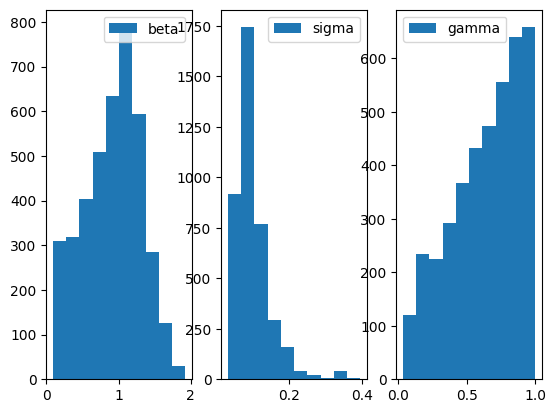

In [ ]:
plt.subplot(1, 3, 1)
plt.hist(samples[:,0] , label='beta')
plt.legend()
plt.subplot(1, 3, 2)
plt.hist(samples[:,1] , label='sigma')
plt.legend()
plt.subplot(1, 3, 3)
plt.hist(samples[:,2] , label='gamma')
plt.legend()
plt.show()

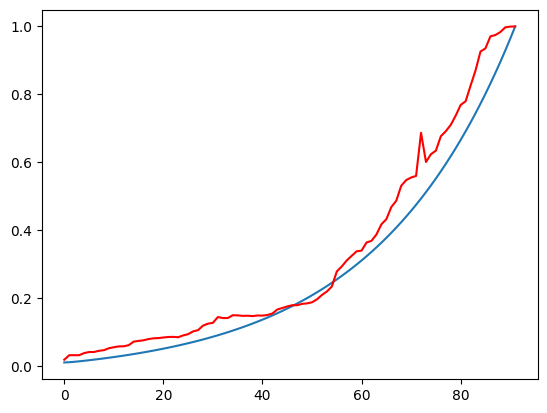

In [ ]:
#Risolvo SEIR con parametri ricavati con inferenza Bayesiana
ret = odeint(seir_model, y0, t, args=(N, beta_mean, sigma_mean, gamma_mean))
S, E, I, R = ret.T

plt.plot(t, (I+R)/max(I+R), label='Modello_SEIR')
plt.plot(t, I_data /max(I_data) , label="Dati reali", color="red")